# Modelagem Preditiva da Insatisfação dos Consumidores

## Objetivo

Nesta etapa do projeto será desenvolvido um modelo de classificação para identificar pedidos com maior probabilidade de resultar em insatisfação do consumidor.

A variável-alvo utilizada será `insatisfeito`, definida anteriormente como:

- **0 — Não insatisfeito:** avaliações de 3 a 5 estrelas;
- **1 — Insatisfeito:** avaliações de 1 ou 2 estrelas.

O processo de modelagem incluirá a seleção das variáveis explicativas, preparação dos dados, separação entre treino e teste, construção de um modelo baseline, treinamento de modelos de classificação e avaliação comparativa de desempenho.

Como a variável-alvo apresenta desbalanceamento entre as classes, a avaliação não será baseada apenas em acurácia. Serão consideradas métricas capazes de avaliar especificamente a identificação dos consumidores insatisfeitos.

In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Preparação dos dados e modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [ ]:
# Conectar o Google Drive

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Verificar os arquivos disponíveis na pasta do projeto

import os

caminho_projeto = '/content/drive/MyDrive'

for raiz, pastas, arquivos in os.walk(caminho_projeto):
    for arquivo in arquivos:
        if arquivo.endswith(('.csv', '.parquet', '.pkl')):
            print(os.path.join(raiz, arquivo))

/content/drive/MyDrive/alunos_base (1).csv
/content/drive/MyDrive/alunos_base.csv
/content/drive/MyDrive/sadipemconsultapublicageralbatch13042026.csv
/content/drive/MyDrive/vendas-por-fatura.csv
/content/drive/MyDrive/bank project marketing.csv
/content/drive/MyDrive/ecommerce_estatistica.csv
/content/drive/MyDrive/semantix-data-project/data/raw/olist_geolocation_dataset.csv
/content/drive/MyDrive/semantix-data-project/data/raw/olist_customers_dataset.csv
/content/drive/MyDrive/semantix-data-project/data/raw/olist_order_items_dataset.csv
/content/drive/MyDrive/semantix-data-project/data/raw/olist_order_payments_dataset.csv
/content/drive/MyDrive/semantix-data-project/data/raw/olist_order_reviews_dataset.csv
/content/drive/MyDrive/semantix-data-project/data/raw/olist_orders_dataset.csv
/content/drive/MyDrive/semantix-data-project/data/raw/product_category_name_translation.csv
/content/drive/MyDrive/semantix-data-project/data/raw/olist_products_dataset.csv
/content/drive/MyDrive/semantix

In [ ]:
from pathlib import Path

# Caminho da pasta com os dados processados
PROCESSED_PATH = Path(
    '/content/drive/MyDrive/semantix-data-project/data/processed'
)

# Arquivo preparado para modelagem
arquivo_modelagem = PROCESSED_PATH / 'olist_modeling_dataset.csv'

# Carregar a base
df_modelagem = pd.read_csv(
    arquivo_modelagem,
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

print("Base de modelagem carregada com sucesso.")
print("Dimensão:", df_modelagem.shape)

display(df_modelagem.head())

Base de modelagem carregada com sucesso.
Dimensão: (95824, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,diferenca_prazo_dias,atrasado,quantidade_itens,valor_produtos,valor_frete,quantidade_produtos_unicos,quantidade_vendedores,valor_pagamento,quantidade_pagamentos,max_parcelas,quantidade_formas_pagamento,review_score,categoria_principal,categoria_principal_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,insatisfeito,frete_percentual,valor_total_pedido,ano_compra,mes_compra,dia_semana_compra,hora_compra
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.44,-7.11,0,1,29.99,8.72,1,1,38.71,3.00,1.00,2.00,4.00,utilidades_domesticas,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0,29.08,38.71,2017,10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.78,-5.36,0,1,118.70,22.76,1,1,141.46,1.00,1.00,1.00,4.00,perfumaria,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,0,19.17,141.46,2018,7,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.39,-17.25,0,1,159.90,19.22,1,1,179.12,1.00,3.00,1.00,5.00,automotivo,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,0,12.02,179.12,2018,8,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.21,-12.98,0,1,45.00,27.20,1,1,72.20,1.00,1.00,1.00,5.00,pet_shop,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,0,60.44,72.20,2017,11,Saturday,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.87,-9.24,0,1,19.90,8.72,1,1,28.62,1.00,1.00,1.00,5.00,papelaria,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,0,43.82,28.62,2018,2,Tuesday,21


## 2. Seleção das variáveis e prevenção de vazamento de dados

Antes do treinamento dos modelos, é necessário definir quais informações podem ser utilizadas como variáveis explicativas.

Neste projeto, será considerado um cenário em que a previsão da insatisfação é realizada após a conclusão da entrega, porém antes de a avaliação do consumidor ser conhecida.

Dessa forma, podem ser utilizadas características relacionadas ao pedido, cliente, valores e desempenho logístico já observados até a entrega.

Variáveis diretamente relacionadas à avaliação, como `review_score`, não serão utilizadas como preditoras, pois fazem parte da informação utilizada para construir a variável-alvo `insatisfeito`.

Essa separação evita o chamado **data leakage**, situação em que o modelo recebe informações que não estariam legitimamente disponíveis no momento da previsão.

In [ ]:
# Listar todas as colunas disponíveis na base

colunas_disponiveis = pd.DataFrame({
    'coluna': df_modelagem.columns,
    'tipo': df_modelagem.dtypes.astype(str).values,
    'nulos': df_modelagem.isna().sum().values
})

display(colunas_disponiveis)

,coluna,tipo,nulos
0,order_id,object,0
1,customer_id,object,0
2,order_status,object,0
3,order_purchase_timestamp,datetime64[ns],0
4,order_approved_at,datetime64[ns],14
5,order_delivered_carrier_date,datetime64[ns],1
6,order_delivered_customer_date,datetime64[ns],0
7,order_estimated_delivery_date,datetime64[ns],0
8,tempo_entrega_dias,float64,0
9,diferenca_prazo_dias,float64,0


### Variáveis selecionadas para modelagem

As variáveis disponíveis foram avaliadas considerando sua utilidade preditiva, disponibilidade no momento definido para a previsão e risco de vazamento de dados.

Foram excluídos:

- identificadores únicos, como `order_id`, `customer_id` e `customer_unique_id`, pois identificam registros, mas não representam características generalizáveis do pedido;
- `review_score`, pois essa variável é utilizada na definição da própria variável-alvo e provocaria vazamento de dados;
- `order_status`, pois a população analisada já foi restrita aos pedidos entregues;
- datas brutas de compra, aprovação e entrega, pois suas principais informações já estão representadas por variáveis derivadas;
- `customer_city` e `customer_zip_code_prefix`, devido à elevada granularidade, priorizando `customer_state` para representar a dimensão geográfica;
- `categoria_principal_english`, por duplicar a informação presente em `categoria_principal`;
- variáveis financeiras redundantes, evitando representar repetidamente o mesmo valor por meio de diferentes colunas.

As variáveis selecionadas combinam características logísticas, financeiras, estruturais, geográficas, temporais e relacionadas ao pagamento.

Como o cenário de previsão ocorre após a conclusão da entrega, variáveis como `tempo_entrega_dias`, `diferenca_prazo_dias` e `atrasado` podem ser utilizadas legitimamente, pois já estão disponíveis nesse momento.

In [ ]:
# Variáveis numéricas selecionadas

features_numericas = [
    'tempo_entrega_dias',
    'diferenca_prazo_dias',
    'atrasado',
    'quantidade_itens',
    'quantidade_produtos_unicos',
    'quantidade_vendedores',
    'valor_produtos',
    'valor_frete',
    'frete_percentual',
    'quantidade_pagamentos',
    'max_parcelas',
    'quantidade_formas_pagamento',
    'ano_compra',
    'mes_compra',
    'hora_compra'
]

# Variáveis categóricas selecionadas

features_categoricas = [
    'categoria_principal',
    'customer_state',
    'dia_semana_compra'
]

features_modelo = (
    features_numericas
    + features_categoricas
)

print("Variáveis numéricas:", len(features_numericas))
print("Variáveis categóricas:", len(features_categoricas))
print("Total de variáveis iniciais:", len(features_modelo))

print("\nVariáveis utilizadas:")
for coluna in features_modelo:
    print("-", coluna)

Variáveis numéricas: 15
Variáveis categóricas: 3
Total de variáveis iniciais: 18

Variáveis utilizadas:
- tempo_entrega_dias
- diferenca_prazo_dias
- atrasado
- quantidade_itens
- quantidade_produtos_unicos
- quantidade_vendedores
- valor_produtos
- valor_frete
- frete_percentual
- quantidade_pagamentos
- max_parcelas
- quantidade_formas_pagamento
- ano_compra
- mes_compra
- hora_compra
- categoria_principal
- customer_state
- dia_semana_compra


In [ ]:
# Variáveis explicativas
X = df_modelagem[
    features_modelo
].copy()

# Variável-alvo
y = df_modelagem[
    'insatisfeito'
].copy()

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

print("\nDistribuição da variável-alvo:")
display(
    y.value_counts()
    .rename_axis('classe')
    .reset_index(name='quantidade')
)

Dimensão de X: (95824, 18)
Dimensão de y: (95824,)

Distribuição da variável-alvo:


,classe,quantidade
0,0,83552
1,1,12272


In [ ]:
# Valores ausentes nas variáveis selecionadas

nulos_features = (
    X.isna()
    .sum()
    .reset_index()
)

nulos_features.columns = [
    'variavel',
    'quantidade_nulos'
]

nulos_features['percentual_nulos'] = (
    nulos_features['quantidade_nulos']
    / len(X)
    * 100
).round(4)

display(
    nulos_features[
        nulos_features['quantidade_nulos'] > 0
    ]
)

,variavel,quantidade_nulos,percentual_nulos
9,quantidade_pagamentos,1,0.00
10,max_parcelas,1,0.00
11,quantidade_formas_pagamento,1,0.00


## 3. Separação dos dados em treino e teste

A base será dividida em conjuntos de treino e teste.

O conjunto de treino será utilizado para ajustar os modelos, enquanto o conjunto de teste permanecerá separado para avaliar o desempenho dos modelos em dados não utilizados durante o treinamento.

Será utilizada uma divisão de **80% para treino e 20% para teste**, com estratificação pela variável-alvo. Essa estratégia preserva aproximadamente a mesma proporção de consumidores insatisfeitos nos dois conjuntos, aspecto especialmente importante devido ao desbalanceamento das classes.

In [ ]:
# Separação entre treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensões dos conjuntos:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print("\nProporção de consumidores insatisfeitos:")
print(f"Base completa: {y.mean() * 100:.2f}%")
print(f"Treino:        {y_train.mean() * 100:.2f}%")
print(f"Teste:         {y_test.mean() * 100:.2f}%")

Dimensões dos conjuntos:
X_train: (76659, 18)
X_test:  (19165, 18)
y_train: (76659,)
y_test:  (19165,)

Proporção de consumidores insatisfeitos:
Base completa: 12.81%
Treino:        12.81%
Teste:         12.80%


In [ ]:
from sklearn.impute import SimpleImputer

print("SimpleImputer importado com sucesso.")

SimpleImputer importado com sucesso.


In [ ]:
# Pipeline para variáveis numéricas
pipeline_numerica = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

# Pipeline para variáveis categóricas
pipeline_categorica = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

# Combinar os dois tipos de pré-processamento
preprocessador = ColumnTransformer(
    transformers=[
        (
            'numericas',
            pipeline_numerica,
            features_numericas
        ),
        (
            'categoricas',
            pipeline_categorica,
            features_categoricas
        )
    ]
)

print("Pré-processador criado com sucesso.")

Pré-processador criado com sucesso.


## 4. Modelo baseline

Antes do treinamento dos modelos preditivos, será estabelecido um modelo baseline.

O baseline funciona como uma referência mínima de desempenho. Como a variável-alvo é desbalanceada, um classificador simples que priorize a classe majoritária pode apresentar acurácia elevada mesmo sem ser capaz de identificar adequadamente consumidores insatisfeitos.

A comparação com o baseline permitirá verificar se os modelos desenvolvidos posteriormente oferecem ganho preditivo efetivo, especialmente na identificação da classe de maior interesse: consumidores insatisfeitos.

In [ ]:
# Modelo baseline: sempre prevê a classe mais frequente

baseline = DummyClassifier(
    strategy='most_frequent'
)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

# Probabilidade da classe positiva
y_prob_baseline = baseline.predict_proba(X_test)[:, 1]

# Métricas
baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_baseline
)

print("RESULTADOS DO BASELINE")
print("-" * 40)
print(f"Acurácia: {baseline_accuracy:.4f}")
print(f"Precisão: {baseline_precision:.4f}")
print(f"Recall:   {baseline_recall:.4f}")
print(f"F1-score: {baseline_f1:.4f}")
print(f"ROC-AUC:  {baseline_roc_auc:.4f}")

RESULTADOS DO BASELINE
----------------------------------------
Acurácia: 0.8720
Precisão: 0.0000
Recall:   0.0000
F1-score: 0.0000
ROC-AUC:  0.5000


### Interpretação do baseline

O modelo baseline apresentou **87,20% de acurácia**, resultado que isoladamente poderia sugerir um bom desempenho. Entretanto, as demais métricas demonstram que o modelo não possui capacidade efetiva de identificar consumidores insatisfeitos.

A precisão, o recall e o F1-score da classe positiva foram iguais a **0**, pois o classificador adotado prevê sempre a classe majoritária, classificando todos os pedidos como não insatisfeitos.

O ROC-AUC de **0,50** também confirma a ausência de capacidade discriminatória entre as classes.

Esse resultado evidencia por que a acurácia não deve ser utilizada isoladamente neste problema. Devido ao desbalanceamento da variável-alvo, será especialmente importante avaliar a capacidade dos modelos de identificar consumidores insatisfeitos por meio de métricas como **recall, precisão, F1-score e ROC-AUC**.

## 5. Regressão Logística

A Regressão Logística será utilizada como primeiro modelo preditivo supervisionado.

Além de funcionar como uma referência sólida para problemas de classificação binária, esse modelo apresenta boa interpretabilidade e permite avaliar a contribuição das variáveis para a probabilidade estimada de insatisfação.

Como a variável-alvo é desbalanceada, será utilizado `class_weight='balanced'`. Essa configuração atribui maior peso aos erros cometidos na classe minoritária, buscando aumentar a capacidade do modelo de identificar consumidores insatisfeitos.

O pré-processamento e o modelo serão integrados em uma única pipeline, garantindo que as transformações sejam ajustadas somente a partir dos dados de treino.

In [ ]:
# Pipeline completa da Regressão Logística

modelo_logistico = Pipeline(
    steps=[
        (
            'preprocessamento',
            preprocessador
        ),
        (
            'modelo',
            LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Treinamento
modelo_logistico.fit(
    X_train,
    y_train
)

print("Regressão Logística treinada com sucesso.")

Regressão Logística treinada com sucesso.


In [ ]:
# Previsões da Regressão Logística

y_pred_logistico = modelo_logistico.predict(
    X_test
)

y_prob_logistico = modelo_logistico.predict_proba(
    X_test
)[:, 1]

# Métricas
log_accuracy = accuracy_score(
    y_test,
    y_pred_logistico
)

log_precision = precision_score(
    y_test,
    y_pred_logistico
)

log_recall = recall_score(
    y_test,
    y_pred_logistico
)

log_f1 = f1_score(
    y_test,
    y_pred_logistico
)

log_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistico
)

print("RESULTADOS DA REGRESSÃO LOGÍSTICA")
print("-" * 40)
print(f"Acurácia: {log_accuracy:.4f}")
print(f"Precisão: {log_precision:.4f}")
print(f"Recall:   {log_recall:.4f}")
print(f"F1-score: {log_f1:.4f}")
print(f"ROC-AUC:  {log_roc_auc:.4f}")

RESULTADOS DA REGRESSÃO LOGÍSTICA
----------------------------------------
Acurácia: 0.8102
Precisão: 0.3477
Recall:   0.5509
F1-score: 0.4264
ROC-AUC:  0.7530


### Interpretação da Regressão Logística

A Regressão Logística apresentou desempenho substancialmente superior ao baseline na identificação de consumidores insatisfeitos.

O modelo alcançou **81,02% de acurácia**, valor inferior aos 87,20% observados no baseline. Entretanto, essa redução é esperada, pois o modelo deixou de simplesmente favorecer a classe majoritária e passou a identificar parte relevante dos consumidores insatisfeitos.

O **recall foi de 55,09%**, indicando que o modelo identificou corretamente pouco mais da metade dos consumidores efetivamente insatisfeitos presentes no conjunto de teste.

A precisão foi de **34,77%**, indicando que, entre os pedidos classificados pelo modelo como potenciais casos de insatisfação, aproximadamente um terço correspondeu efetivamente à classe positiva.

O equilíbrio entre precisão e recall resultou em **F1-score de 42,64%**.

O **ROC-AUC de 0,7530** demonstra capacidade discriminatória consideravelmente superior ao baseline, que apresentou ROC-AUC de 0,50.

Os resultados mostram que a Regressão Logística possui capacidade preditiva relevante, embora ainda exista espaço para melhorar o equilíbrio entre a identificação dos consumidores insatisfeitos e a ocorrência de falsos positivos.

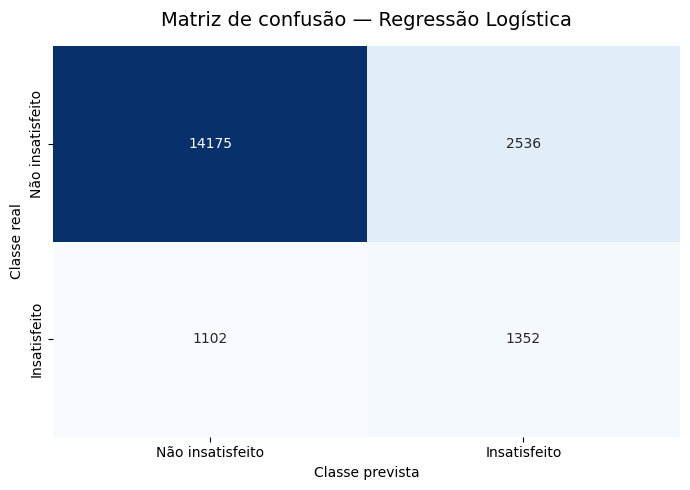

In [ ]:
# Matriz de confusão da Regressão Logística

matriz_logistica = confusion_matrix(
    y_test,
    y_pred_logistico
)

plt.figure(figsize=(7, 5))

ax = sns.heatmap(
    matriz_logistica,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=[
        'Não insatisfeito',
        'Insatisfeito'
    ],
    yticklabels=[
        'Não insatisfeito',
        'Insatisfeito'
    ]
)

ax.set_title(
    'Matriz de confusão — Regressão Logística',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Classe prevista')
ax.set_ylabel('Classe real')

plt.tight_layout()
plt.show()

## 6. Random Forest

O Random Forest será utilizado como segundo modelo de classificação.

Diferentemente da Regressão Logística, esse algoritmo é capaz de representar relações não lineares e interações mais complexas entre as características dos pedidos.

Para lidar com o desbalanceamento da variável-alvo, será utilizado `class_weight='balanced'`, atribuindo maior importância à classe minoritária durante o treinamento.

O desempenho será avaliado utilizando as mesmas métricas aplicadas anteriormente, permitindo uma comparação consistente entre os modelos.

In [ ]:
# Pipeline do Random Forest

modelo_random_forest = Pipeline(
    steps=[
        (
            'preprocessamento',
            preprocessador
        ),
        (
            'modelo',
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Treinamento
modelo_random_forest.fit(
    X_train,
    y_train
)

print("Random Forest treinado com sucesso.")

Random Forest treinado com sucesso.


In [ ]:
# Previsões do Random Forest

y_pred_rf = modelo_random_forest.predict(
    X_test
)

y_prob_rf = modelo_random_forest.predict_proba(
    X_test
)[:, 1]

# Métricas
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("RESULTADOS DO RANDOM FOREST")
print("-" * 40)
print(f"Acurácia: {rf_accuracy:.4f}")
print(f"Precisão: {rf_precision:.4f}")
print(f"Recall:   {rf_recall:.4f}")
print(f"F1-score: {rf_f1:.4f}")
print(f"ROC-AUC:  {rf_roc_auc:.4f}")

RESULTADOS DO RANDOM FOREST
----------------------------------------
Acurácia: 0.8426
Precisão: 0.4089
Recall:   0.5143
F1-score: 0.4556
ROC-AUC:  0.7595


## 7. Comparação dos modelos

Os modelos serão comparados utilizando as mesmas métricas de avaliação no conjunto de teste.

Devido ao desbalanceamento da variável-alvo, a escolha do modelo não será baseada exclusivamente na acurácia. Serão considerados conjuntamente o recall, a precisão, o F1-score e o ROC-AUC, com atenção especial à capacidade de identificar consumidores insatisfeitos.

In [ ]:
# Comparação das métricas dos modelos

comparacao_modelos = pd.DataFrame({
    'Modelo': [
        'Baseline',
        'Regressão Logística',
        'Random Forest'
    ],
    'Acurácia': [
        baseline_accuracy,
        log_accuracy,
        rf_accuracy
    ],
    'Precisão': [
        baseline_precision,
        log_precision,
        rf_precision
    ],
    'Recall': [
        baseline_recall,
        log_recall,
        rf_recall
    ],
    'F1-score': [
        baseline_f1,
        log_f1,
        rf_f1
    ],
    'ROC-AUC': [
        baseline_roc_auc,
        log_roc_auc,
        rf_roc_auc
    ]
})

comparacao_exibicao = comparacao_modelos.copy()

for coluna in [
    'Acurácia',
    'Precisão',
    'Recall',
    'F1-score',
    'ROC-AUC'
]:
    comparacao_exibicao[coluna] = (
        comparacao_exibicao[coluna] * 100
    ).round(2)

display(comparacao_exibicao)

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC-AUC
0,Baseline,87.20,0.00,0.00,0.00,50.00
1,Regressão Logística,81.02,34.77,55.09,42.64,75.30
2,Random Forest,84.26,40.89,51.43,45.56,75.95


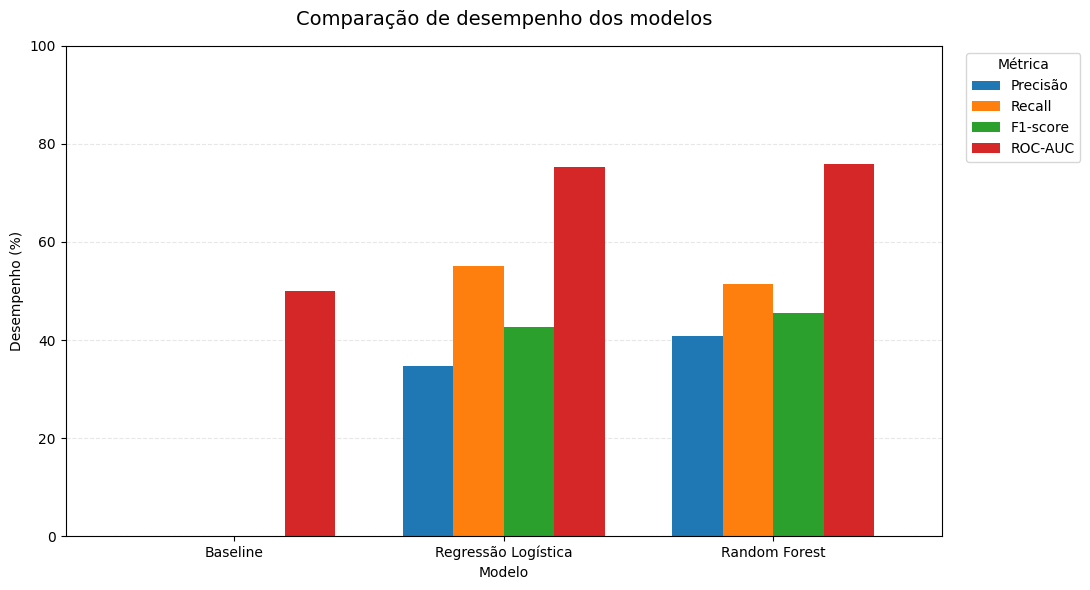

In [ ]:
# Preparar os dados para visualização

comparacao_grafico = (
    comparacao_modelos
    .set_index('Modelo')
    [
        [
            'Precisão',
            'Recall',
            'F1-score',
            'ROC-AUC'
        ]
    ]
    * 100
)

ax = comparacao_grafico.plot(
    kind='bar',
    figsize=(11, 6),
    width=0.75
)

ax.set_title(
    'Comparação de desempenho dos modelos',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Modelo')
ax.set_ylabel('Desempenho (%)')

ax.set_ylim(0, 100)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

plt.xticks(
    rotation=0
)

plt.legend(
    title='Métrica',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Interpretação da comparação

Os dois modelos supervisionados apresentaram capacidade preditiva substancialmente superior ao baseline para a identificação de consumidores insatisfeitos.

A **Regressão Logística apresentou o maior recall (55,09%)**, sendo capaz de identificar uma proporção ligeiramente maior dos consumidores efetivamente insatisfeitos.

O **Random Forest**, entretanto, apresentou melhor desempenho em precisão (**40,89%**), F1-score (**45,56%**) e ROC-AUC (**75,95%**), além de alcançar acurácia de **84,26%**.

O maior F1-score do Random Forest indica um equilíbrio superior entre precisão e recall no limiar de classificação utilizado. Seu ROC-AUC também foi ligeiramente superior, indicando melhor capacidade global de discriminação entre consumidores insatisfeitos e não insatisfeitos.

Dessa forma, considerando conjuntamente as métricas avaliadas, o **Random Forest apresenta o melhor desempenho geral entre os modelos testados**. Entretanto, caso o objetivo operacional priorizasse maximizar a identificação de consumidores insatisfeitos, a Regressão Logística apresentaria vantagem no recall utilizando o limiar padrão atual.

A escolha final do modelo deve, portanto, considerar não apenas o desempenho estatístico, mas também o custo de falsos positivos e falsos negativos no contexto de negócio.

## 8. Interpretabilidade do modelo selecionado

Após a comparação dos modelos, o Random Forest foi selecionado por apresentar o melhor desempenho geral, considerando conjuntamente precisão, F1-score e ROC-AUC.

Além do desempenho preditivo, é importante compreender quais características possuem maior participação nas decisões realizadas pelo modelo.

Nesta etapa, será analisada a importância das variáveis calculada pelo Random Forest. Como as variáveis categóricas foram transformadas por One-Hot Encoding, cada categoria transformada poderá aparecer individualmente na análise.

A importância de uma variável representa sua contribuição para as divisões realizadas pelas árvores do modelo e não deve ser interpretada como evidência de causalidade.

In [ ]:
# Recuperar o preprocessador e o Random Forest treinados

preprocessador_rf = modelo_random_forest.named_steps[
    'preprocessamento'
]

random_forest_treinado = modelo_random_forest.named_steps[
    'modelo'
]

# Recuperar os nomes das variáveis após o pré-processamento
nomes_features = preprocessador_rf.get_feature_names_out()

# Recuperar a importância calculada pelo Random Forest
importancias = random_forest_treinado.feature_importances_

# Criar tabela
importancia_features = pd.DataFrame({
    'variavel': nomes_features,
    'importancia': importancias
})

importancia_features = (
    importancia_features
    .sort_values(
        'importancia',
        ascending=False
    )
    .reset_index(drop=True)
)

# Percentual para facilitar a interpretação
importancia_features['importancia_percentual'] = (
    importancia_features['importancia'] * 100
).round(2)

display(
    importancia_features.head(20)
)

,variavel,importancia,importancia_percentual
0,numericas__diferenca_prazo_dias,0.28,28.49
1,numericas__atrasado,0.20,19.91
2,numericas__tempo_entrega_dias,0.19,19.02
3,numericas__quantidade_itens,0.08,7.86
4,numericas__valor_frete,0.04,4.20
5,numericas__quantidade_produtos_unicos,0.03,2.94
6,numericas__quantidade_vendedores,0.03,2.65
7,numericas__mes_compra,0.02,2.04
8,numericas__valor_produtos,0.02,1.98
9,numericas__frete_percentual,0.02,1.78


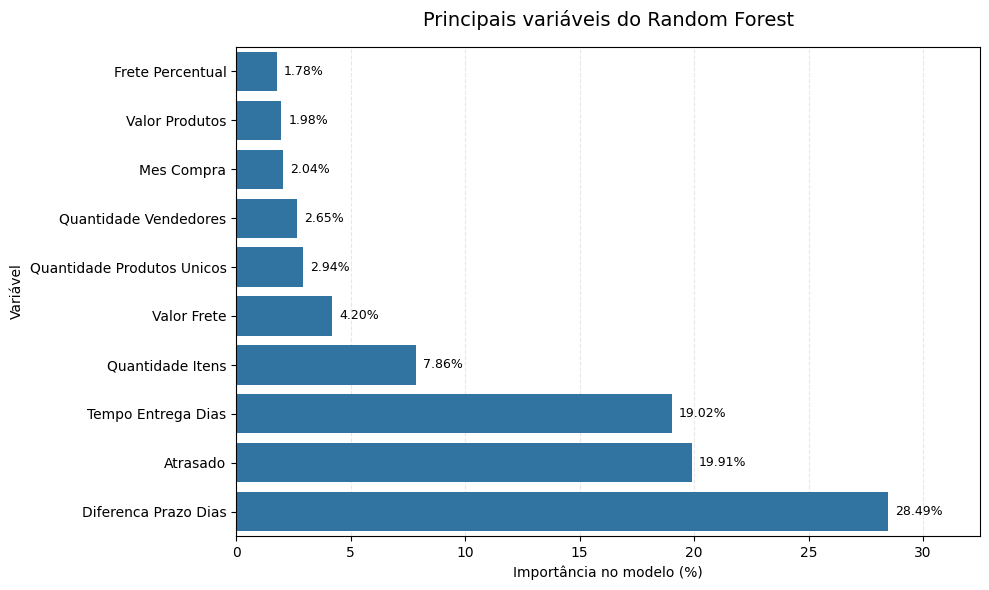

In [ ]:
# Selecionar as 10 variáveis mais importantes

top10_importancias = (
    importancia_features
    .head(10)
    .copy()
)

# Limpar os nomes gerados pela pipeline
top10_importancias['variavel_exibicao'] = (
    top10_importancias['variavel']
    .str.replace('numericas__', '', regex=False)
    .str.replace('categoricas__', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
)

# Ordenar para o gráfico horizontal
top10_importancias = (
    top10_importancias
    .sort_values(
        'importancia_percentual',
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top10_importancias,
    x='importancia_percentual',
    y='variavel_exibicao',
    orient='h'
)

ax.set_title(
    'Principais variáveis do Random Forest',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Importância no modelo (%)')
ax.set_ylabel('Variável')

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

ax.set_xlim(
    0,
    top10_importancias['importancia_percentual'].max() + 4
)

# Valores ao final das barras
for barra in ax.patches:
    valor = barra.get_width()

    ax.text(
        valor + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f'{valor:.2f}%',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretação da importância das variáveis

A análise de importância das variáveis reforça os padrões identificados anteriormente na análise exploratória.

As três características de maior importância no Random Forest estão diretamente relacionadas ao desempenho logístico. A variável `diferenca_prazo_dias` apresentou a maior importância individual, com **28,49%**, seguida por `atrasado`, com **19,91%**, e `tempo_entrega_dias`, com **19,02%**.

Em conjunto, essas três variáveis representam aproximadamente **67,42% da importância total calculada pelo modelo**, evidenciando o papel predominante das características relacionadas à entrega na classificação dos consumidores.

A `quantidade_itens` aparece na sequência, com **7,86%**, enquanto `valor_frete` representa **4,20%**. Outras características relacionadas à estrutura do pedido, período da compra e valores financeiros apresentaram contribuições individuais menores.

Os resultados do modelo são consistentes com a análise exploratória, na qual pedidos atrasados, entregas mais demoradas e menor antecedência em relação ao prazo estimado apresentaram maiores níveis de insatisfação.

Entretanto, a importância calculada pelo Random Forest representa a contribuição das variáveis para as decisões realizadas pelas árvores e **não indica causalidade nem o sentido do efeito**. Além disso, variáveis relacionadas entre si podem compartilhar ou redistribuir importância dentro do modelo.

## 9. Curva ROC e capacidade discriminatória

A Curva ROC permite avaliar a capacidade dos modelos de distinguir consumidores insatisfeitos e não insatisfeitos considerando diferentes limiares de classificação.

A área sob a curva, denominada ROC-AUC, resume essa capacidade discriminatória. Valores mais próximos de 1 indicam maior capacidade de separação entre as classes, enquanto um valor próximo de 0,50 representa desempenho semelhante ao de uma classificação sem capacidade discriminatória.

A análise complementa as métricas calculadas utilizando o limiar padrão de classificação.

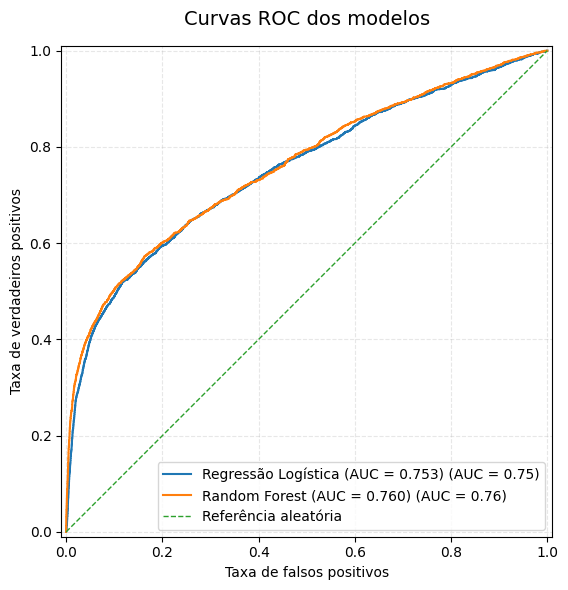

In [ ]:
# Curvas ROC dos modelos supervisionados

plt.figure(figsize=(8, 6))

ax = plt.gca()

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistico,
    name=f'Regressão Logística (AUC = {log_roc_auc:.3f})',
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name=f'Random Forest (AUC = {rf_roc_auc:.3f})',
    ax=ax
)

# Linha de referência para um classificador sem capacidade discriminatória
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    label='Referência aleatória'
)

ax.set_title(
    'Curvas ROC dos modelos',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Taxa de falsos positivos')
ax.set_ylabel('Taxa de verdadeiros positivos')

ax.grid(
    linestyle='--',
    alpha=0.3
)

ax.legend(
    loc='lower right'
)

plt.tight_layout()
plt.show()

### Interpretação da Curva ROC

Os dois modelos supervisionados apresentaram capacidade discriminatória consideravelmente superior ao baseline.

A Regressão Logística apresentou ROC-AUC de **0,7530**, enquanto o Random Forest alcançou **0,7595**.

A proximidade entre os resultados indica que ambos possuem capacidade semelhante de ordenar pedidos de acordo com o risco estimado de insatisfação. O Random Forest apresentou uma vantagem discreta nessa métrica.

Esse resultado reforça que a superioridade do Random Forest não é ampla em todos os aspectos. Enquanto apresenta melhor precisão, F1-score e ROC-AUC no limiar padrão, a Regressão Logística mantém maior recall.

A definição do modelo e do limiar de classificação deve, portanto, considerar o objetivo operacional e o custo associado aos diferentes tipos de erro.

In [ ]:
# Avaliar diferentes limiares de classificação do Random Forest

resultados_threshold = []

for threshold in np.arange(0.20, 0.71, 0.05):

    y_pred_threshold = (
        y_prob_rf >= threshold
    ).astype(int)

    resultados_threshold.append({
        'Limiar': threshold,
        'Precisão': precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'F1-score': f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    resultados_threshold
)

threshold_df[
    [
        'Precisão',
        'Recall',
        'F1-score'
    ]
] = (
    threshold_df[
        [
            'Precisão',
            'Recall',
            'F1-score'
        ]
    ] * 100
).round(2)

threshold_df['Limiar'] = (
    threshold_df['Limiar']
    .round(2)
)

display(threshold_df)

,Limiar,Precisão,Recall,F1-score
0,0.20,12.80,100.00,22.70
1,0.25,12.80,100.00,22.70
2,0.30,12.91,99.67,22.86
3,0.35,18.81,79.46,30.42
4,0.40,29.53,60.92,39.78
5,0.45,34.87,55.38,42.80
6,0.50,40.89,51.43,45.56
7,0.55,46.51,47.47,46.99
8,0.60,53.89,42.34,47.42
9,0.65,60.20,38.59,47.03


### Interpretação dos limiares de classificação

A alteração do limiar de classificação evidencia o trade-off entre precisão e recall do Random Forest.

Nos limiares mais baixos, o modelo identifica praticamente todos os consumidores insatisfeitos, porém com baixa precisão. No limiar de 0,30, por exemplo, o recall alcança 99,67%, enquanto a precisão é de apenas 12,91%, indicando um número elevado de falsos positivos.

À medida que o limiar aumenta, a precisão melhora e o recall diminui. No limiar padrão de 0,50, o modelo apresenta **40,89% de precisão, 51,43% de recall e F1-score de 45,56%**.

Entre os limiares avaliados, o maior F1-score foi observado em **0,60**, alcançando **47,42%**, com precisão de **53,89%** e recall de **42,34%**. Esse limiar oferece maior equilíbrio estatístico entre precisão e recall, porém reduz a capacidade de identificar todos os consumidores efetivamente insatisfeitos.

Como não foram definidos custos específicos para falsos positivos e falsos negativos no contexto de negócio, será mantido o **limiar padrão de 0,50** como referência principal do modelo. A análise demonstra, entretanto, que o limiar pode ser ajustado conforme a estratégia operacional: limiares menores podem ser utilizados quando a prioridade for ampliar a identificação de consumidores em risco, enquanto limiares maiores podem ser adotados quando o custo de intervenções sobre falsos positivos for mais relevante.

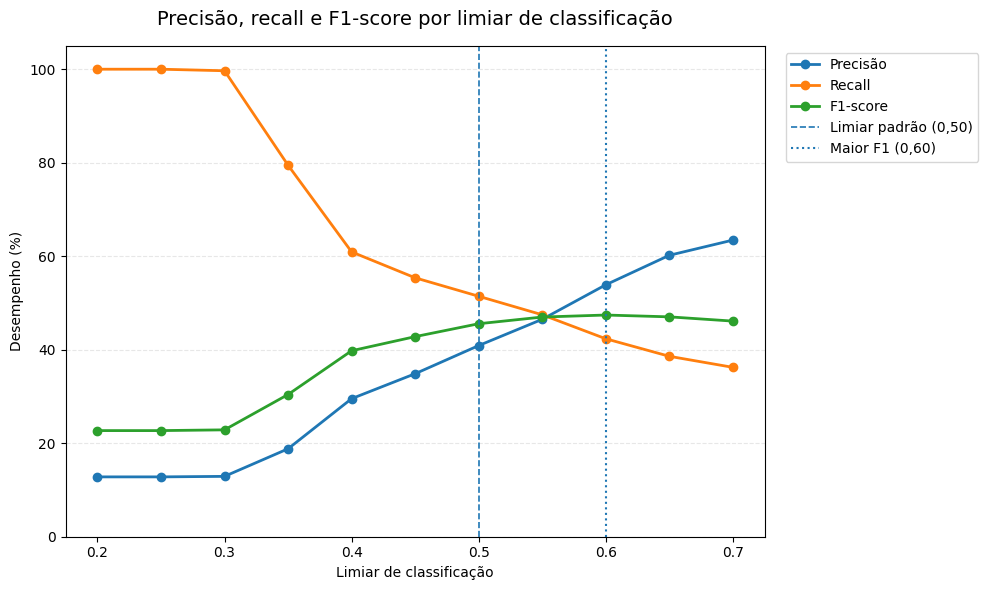

In [ ]:
# Evolução das métricas conforme o limiar de classificação

threshold_grafico = threshold_df.copy()

plt.figure(figsize=(10, 6))

ax = plt.gca()

ax.plot(
    threshold_grafico['Limiar'],
    threshold_grafico['Precisão'],
    marker='o',
    linewidth=2,
    label='Precisão'
)

ax.plot(
    threshold_grafico['Limiar'],
    threshold_grafico['Recall'],
    marker='o',
    linewidth=2,
    label='Recall'
)

ax.plot(
    threshold_grafico['Limiar'],
    threshold_grafico['F1-score'],
    marker='o',
    linewidth=2,
    label='F1-score'
)

# Limiar padrão
ax.axvline(
    x=0.50,
    linestyle='--',
    linewidth=1.2,
    label='Limiar padrão (0,50)'
)

# Melhor F1 entre os valores testados
ax.axvline(
    x=0.60,
    linestyle=':',
    linewidth=1.5,
    label='Maior F1 (0,60)'
)

ax.set_title(
    'Precisão, recall e F1-score por limiar de classificação',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Limiar de classificação')
ax.set_ylabel('Desempenho (%)')

ax.set_ylim(0, 105)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## 10. Conclusão da modelagem

A etapa de modelagem teve como objetivo desenvolver uma abordagem capaz de identificar pedidos associados a maior probabilidade de insatisfação do consumidor.

Inicialmente, o modelo baseline apresentou **87,20% de acurácia**, mas foi incapaz de identificar consumidores insatisfeitos, apresentando recall, precisão e F1-score iguais a zero. Esse resultado evidenciou a inadequação da acurácia como métrica isolada diante do desbalanceamento da variável-alvo.

A Regressão Logística apresentou avanço significativo, alcançando **55,09% de recall**, **34,77% de precisão**, **42,64% de F1-score** e ROC-AUC de **0,7530**.

O Random Forest apresentou o melhor desempenho geral entre os modelos avaliados, alcançando:

- **Acurácia:** 84,26%
- **Precisão:** 40,89%
- **Recall:** 51,43%
- **F1-score:** 45,56%
- **ROC-AUC:** 0,7595

Embora a Regressão Logística tenha apresentado recall ligeiramente superior, o Random Forest obteve melhor precisão, F1-score e ROC-AUC, sendo selecionado como modelo de melhor desempenho geral.

A análise de importância das variáveis mostrou forte predominância dos indicadores logísticos. `diferenca_prazo_dias`, `atrasado` e `tempo_entrega_dias` concentraram aproximadamente **67,42% da importância calculada pelo Random Forest**, resultado consistente com os padrões identificados anteriormente na análise exploratória.

A avaliação de diferentes limiares de classificação também demonstrou que o comportamento do modelo pode ser adaptado às necessidades do negócio. Entre os limiares testados, 0,60 apresentou o maior F1-score, porém com redução do recall. Na ausência de custos definidos para falsos positivos e falsos negativos, o limiar padrão de **0,50** foi mantido como referência principal.

De forma geral, os resultados demonstram que é possível identificar padrões associados à insatisfação dos consumidores a partir das características dos pedidos, com destaque para o desempenho logístico.

## 11. Implicações para o negócio

Os resultados obtidos permitem transformar os achados analíticos em possíveis direcionamentos para a operação.

### Monitoramento de pedidos com risco logístico

A forte relevância das variáveis relacionadas à entrega sugere que pedidos com deterioração do desempenho logístico merecem atenção prioritária. Atrasos e entregas próximas ou posteriores ao prazo estimado podem ser utilizados como sinais para ações de acompanhamento do consumidor.

### Priorização de consumidores em risco

As probabilidades produzidas pelo modelo podem ser utilizadas para ordenar pedidos conforme o risco estimado de insatisfação, permitindo que equipes de atendimento priorizem casos potencialmente mais críticos.

### Ajuste da estratégia conforme o custo operacional

O limiar de classificação pode ser adaptado conforme a estratégia da empresa. Uma operação que priorize evitar consumidores insatisfeitos pode utilizar limiares menores para aumentar o recall, enquanto operações com maior custo de intervenção podem adotar limiares mais altos para aumentar a precisão.

### Investigação de períodos críticos

A análise exploratória identificou períodos nos quais o crescimento da insatisfação ocorreu simultaneamente ao aumento dos atrasos. O acompanhamento temporal desses indicadores pode auxiliar na identificação antecipada de deteriorações operacionais.

### Segmentação complementar

Categoria do produto, localização geográfica, características financeiras e estrutura dos pedidos também apresentaram diferenças entre os grupos e podem complementar estratégias de segmentação e investigação operacional.

Os resultados devem ser utilizados como instrumentos de apoio à decisão. As associações e importâncias identificadas pelo modelo não representam, isoladamente, relações causais.

## 12. Limitações

Apesar dos resultados obtidos, algumas limitações devem ser consideradas.

- A definição de insatisfação foi construída a partir das avaliações de 1 e 2 estrelas, enquanto avaliações de 3 a 5 estrelas foram agrupadas como não insatisfeitas.
- O modelo foi desenvolvido a partir de dados históricos e seu desempenho pode variar em novos períodos ou diante de mudanças no comportamento dos consumidores e na operação.
- O cenário de previsão definido ocorre após a conclusão da entrega e antes da avaliação do consumidor. Por esse motivo, informações logísticas observadas após a entrega puderam ser utilizadas como variáveis explicativas.
- As importâncias calculadas pelo Random Forest não representam causalidade.
- Variáveis correlacionadas, especialmente os indicadores relacionados à logística, podem compartilhar informação e distribuir importância entre si.
- Não foram definidos custos financeiros específicos para falsos positivos e falsos negativos, razão pela qual o limiar padrão de 0,50 foi mantido como referência principal.
- Os resultados representam o comportamento observado na base analisada e não devem ser generalizados automaticamente para outros contextos de comércio eletrônico.

In [ ]:
# Resumo final da modelagem

print("MODELAGEM PREDITIVA CONCLUÍDA")
print("-" * 50)

print("Modelo selecionado: Random Forest")
print(f"Acurácia: {rf_accuracy:.2%}")
print(f"Precisão: {rf_precision:.2%}")
print(f"Recall:   {rf_recall:.2%}")
print(f"F1-score: {rf_f1:.2%}")
print(f"ROC-AUC:  {rf_roc_auc:.4f}")

print("-" * 50)
print("Limiar principal de classificação: 0.50")
print("Maior F1 entre os limiares avaliados: 0.60")
print("-" * 50)

print("Notebook de modelagem concluído com sucesso.")

MODELAGEM PREDITIVA CONCLUÍDA
--------------------------------------------------
Modelo selecionado: Random Forest
Acurácia: 84.26%
Precisão: 40.89%
Recall:   51.43%
F1-score: 45.56%
ROC-AUC:  0.7595
--------------------------------------------------
Limiar principal de classificação: 0.50
Maior F1 entre os limiares avaliados: 0.60
--------------------------------------------------
Notebook de modelagem concluído com sucesso.
